Importing Libraries

In [50]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# Scikit-Learn — Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Scikit-Learn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-Learn — Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


In [14]:
# Load dataset
df = pd.read_csv('flight_delay.csv')

# Clean corrupted values (e.g. '77.8_err') by coercing to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print()
print('=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 694  |  Columns: 8

=== First 5 Rows ===


,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
0,23.0,61.0,2303.0,1.0,67.6,13.8,79.0,0
1,20.0,75.0,338.0,2.0,71.5,1.4,89.0,1
2,20.0,167.0,1257.0,0.0,62.1,7.5,13.0,0
3,11.0,87.0,1274.0,2.0,12.4,9.1,64.0,0
4,5.0,56.0,2567.0,2.0,73.7,7.5,19.0,0


In [15]:
# Data types and basic info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   departure_hour          694 non-null    float64
 1   scheduled_duration_min  694 non-null    float64
 2   distance_miles          694 non-null    float64
 3   num_connections         694 non-null    float64
 4   wind_speed_kmh          668 non-null    float64
 5   visibility_km           674 non-null    float64
 6   prev_flight_delay_min   694 non-null    float64
 7   is_delayed              694 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 43.5 KB


In [16]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
count,694.00,694.00,694.00,694.00,668.00,674.00,694.00,694.00
mean,11.31,204.73,1549.95,0.98,41.66,8.01,42.47,0.49
std,7.10,89.88,849.52,0.83,29.55,4.01,26.39,0.50
min,0.00,45.00,0.00,0.00,0.00,-3.00,-50.00,0.00
25%,5.00,126.50,778.00,0.00,20.85,4.60,19.00,0.00
50%,11.00,209.00,1538.50,1.00,42.00,8.10,42.00,0.00
75%,18.00,281.00,2303.00,2.00,61.60,11.40,64.00,1.00
max,28.00,359.00,2999.00,2.00,500.00,15.00,89.00,1.00


In [17]:
# Missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
                Missing Count  Missing %
wind_speed_kmh             26       3.75
visibility_km              20       2.88


Target Variable Distribution (Delayed vs Not Delayed)

This chart shows how many flights were delayed and how many arrived on time.

By looking at the chart, we can quickly understand whether flight delays are common or rare in the dataset. If the delayed flights occupy a large portion of the chart, it means delays happen frequently. If the non-delayed flights dominate, most flights operate on schedule.

In [18]:
# Target variable distribution
print('=== Target Variable: is_delayed ===')
target_counts = df['is_delayed'].value_counts()
print(target_counts)
print(f'\nClass Balance: {target_counts[0]} Not Delayed ({target_counts[0]/len(df)*100:.1f}%)  |  {target_counts[1]} Delayed ({target_counts[1]/len(df)*100:.1f}%)')

=== Target Variable: is_delayed ===
is_delayed
0    353
1    341
Name: count, dtype: int64

Class Balance: 353 Not Delayed (50.9%)  |  341 Delayed (49.1%)


Pie Chart of Delayed vs Non-Delayed Flights

This pie chart divides all flights into two groups: delayed flights and flights that were not delayed.

Each slice shows the percentage of flights belonging to each group. A larger slice means that category occurs more often.

This helps us understand the proportion of delayed flights compared to flights that operated normally.

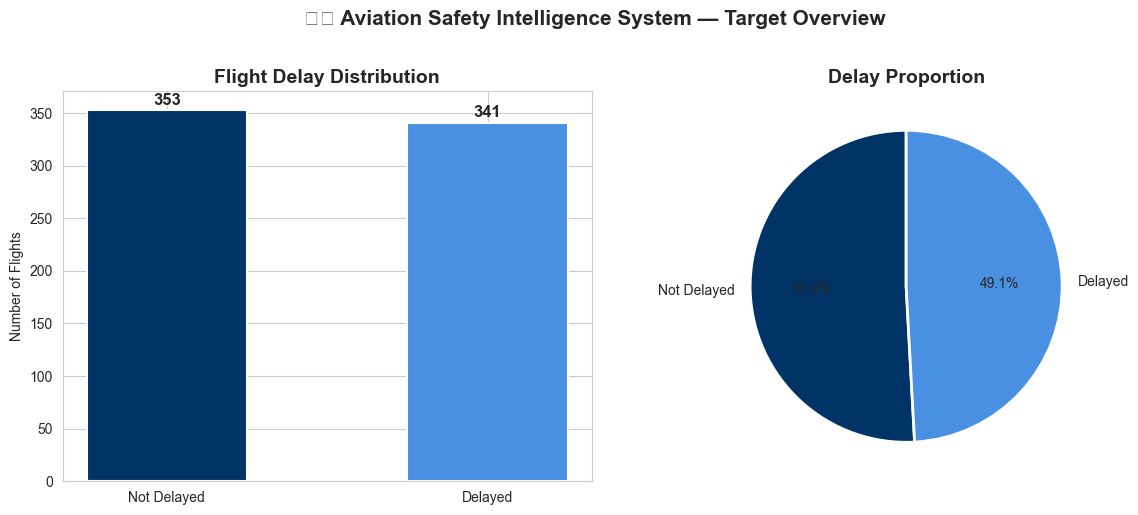

 The dataset is nearly balanced — ideal for classification without resampling.


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#003366', '#4A90E2']
labels = ['Not Delayed', 'Delayed']
counts = df['is_delayed'].value_counts().sort_index()
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Flight Delay Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Flights')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Delay Proportion', fontsize=14, fontweight='bold')

plt.suptitle('✈️ Aviation Safety Intelligence System — Target Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(' The dataset is nearly balanced — ideal for classification without resampling.')

Feature Distribution Histograms

(Departure Hour, Distance, Wind Speed, Visibility, Previous Delay, etc.)

These charts show how flight characteristics are spread across the dataset.

For example:

Some flights depart early in the morning.
Others depart during the afternoon or night.
Some flights travel short distances while others travel long distances.

By comparing delayed and non-delayed flights, we can identify patterns that may contribute to delays.

For instance, if many delayed flights occur during specific hours, those times may have a higher risk of delays.

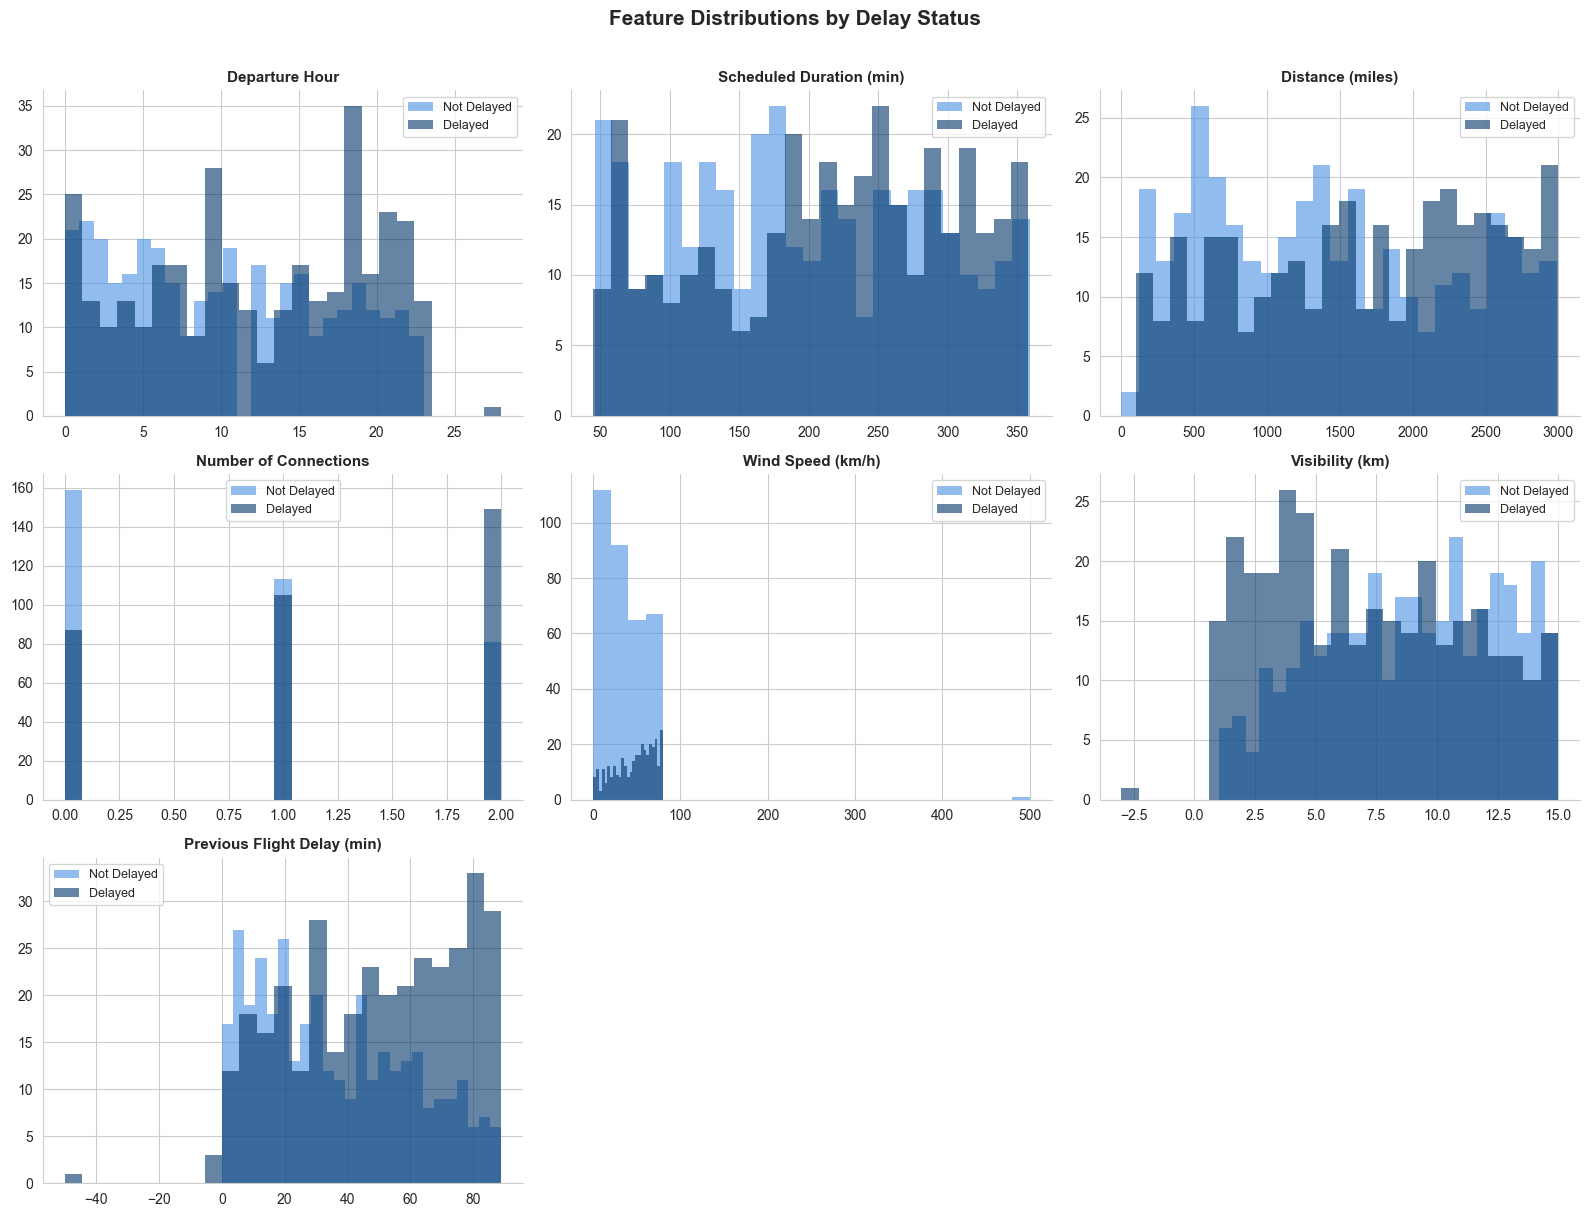

In [20]:
features = ['departure_hour', 'scheduled_duration_min', 'distance_miles',
            'num_connections', 'wind_speed_kmh', 'visibility_km', 'prev_flight_delay_min']

feature_labels = {
    'departure_hour': 'Departure Hour',
    'scheduled_duration_min': 'Scheduled Duration (min)',
    'distance_miles': 'Distance (miles)',
    'num_connections': 'Number of Connections',
    'wind_speed_kmh': 'Wind Speed (km/h)',
    'visibility_km': 'Visibility (km)',
    'prev_flight_delay_min': 'Previous Flight Delay (min)'
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    for val, color, label in [(0, '#4A90E2', 'Not Delayed'), (1, '#003366', 'Delayed')]:
        axes[i].hist(df[df['is_delayed'] == val][feat].dropna(), bins=25,
                     alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(feature_labels[feat], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide the extra subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.suptitle('Feature Distributions by Delay Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Delay Rate by Departure Hour

This chart shows how often delays occur at different times of the day.

Each bar represents a departure hour, while the height of the bar shows the percentage of flights delayed during that hour.

The chart helps identify periods when delays are more likely to occur.

For example, if evening flights show higher delay rates, congestion or operational challenges during that period may be contributing factors.

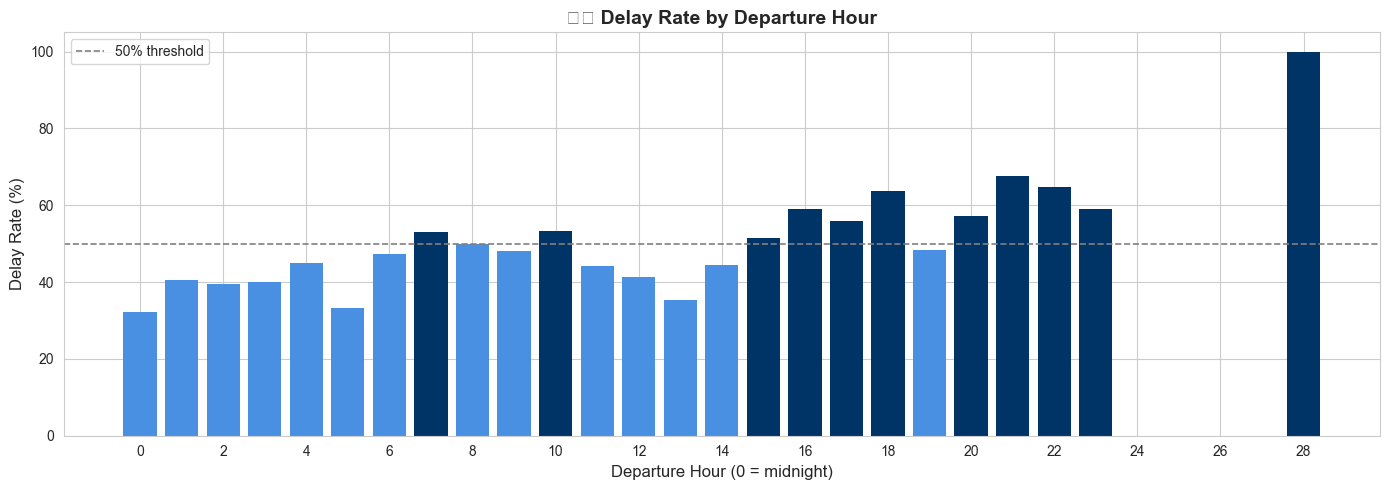

  Peak delay risk hour: 28:00 with 100.0% delay rate


In [48]:
hourly_delay = df.groupby('departure_hour')['is_delayed'].mean() * 100

plt.figure(figsize=(14, 5))
plt.bar(hourly_delay.index, hourly_delay.values,
        color=['#003366' if v > 50 else '#4A90E2' for v in hourly_delay.values],
        edgecolor='none', width=0.8)
plt.axhline(50, color='gray', linestyle='--', linewidth=1.2, label='50% threshold')
plt.xlabel('Departure Hour (0 = midnight)', fontsize=12)
plt.ylabel('Delay Rate (%)', fontsize=12)
plt.title('✈️ Delay Rate by Departure Hour', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(range(0, 29, 2))
plt.tight_layout()
plt.show()

peak_hour = hourly_delay.idxmax()
print(f'  Peak delay risk hour: {int(peak_hour):02d}:00 with {hourly_delay.max():.1f}% delay rate')

Correlation Heatmap

This chart shows how different flight factors are related to each other.

Darker or stronger colors indicate a stronger relationship, while lighter colors indicate a weaker relationship.

The heatmap helps identify which variables are closely connected and which factors may have the strongest influence on flight delays.

This information is useful when selecting features for machine learning models.

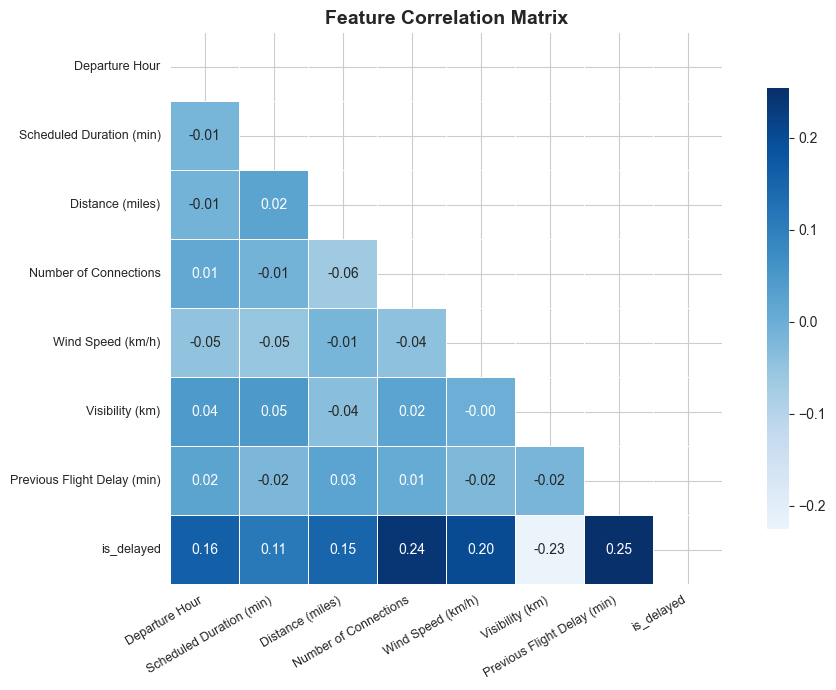

=== Feature Correlation with is_delayed ===
prev_flight_delay_min     0.254
num_connections           0.243
wind_speed_kmh            0.200
departure_hour            0.159
distance_miles            0.149
scheduled_duration_min    0.112
visibility_km            -0.225
Name: is_delayed, dtype: float64


In [22]:
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            xticklabels=[feature_labels.get(c, c) for c in corr.columns],
            yticklabels=[feature_labels.get(c, c) for c in corr.index])
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Correlation with target
print('=== Feature Correlation with is_delayed ===')
print(corr['is_delayed'].drop('is_delayed').sort_values(ascending=False).round(3))

Boxplots Comparing Delayed and Non-Delayed Flights

These charts compare the characteristics of delayed flights and non-delayed flights.

The middle line represents the typical value, while the box shows where most observations fall.

If the delayed flights have noticeably higher or lower values than non-delayed flights, that feature may play an important role in predicting delays.

The chart also highlights unusual values called outliers.

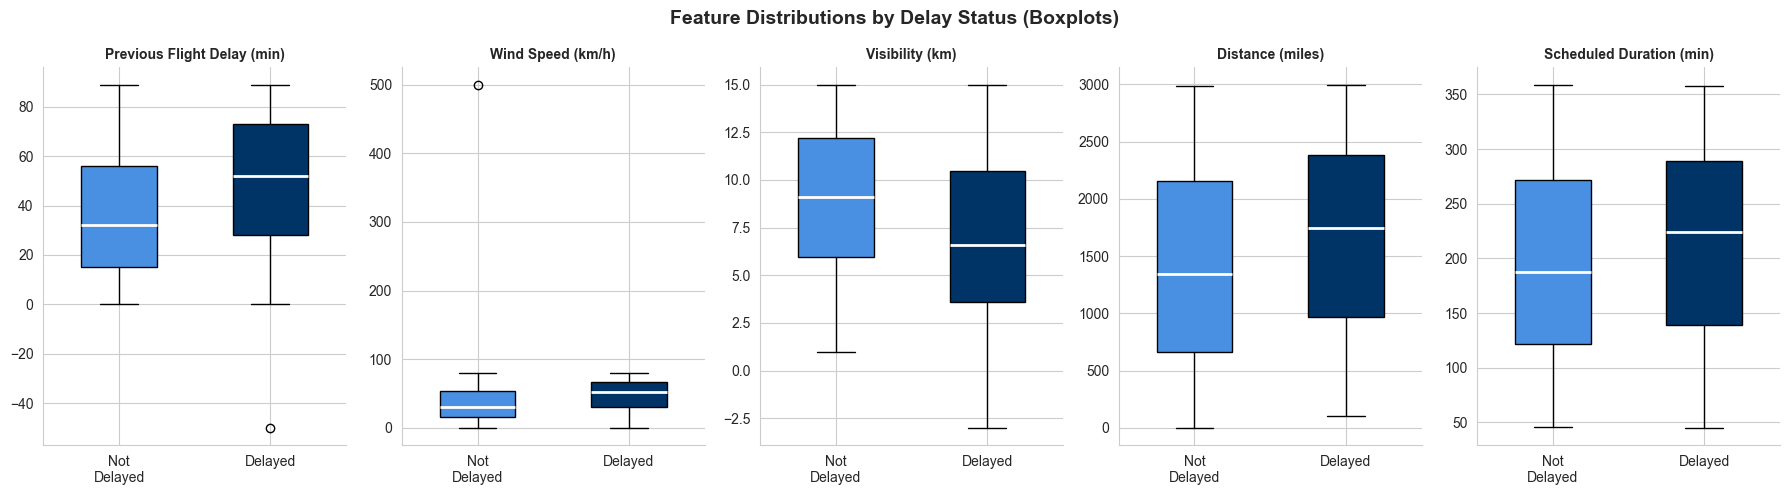

In [23]:
numeric_features = ['prev_flight_delay_min', 'wind_speed_kmh', 'visibility_km',
                    'distance_miles', 'scheduled_duration_min']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, feat in enumerate(numeric_features):
    data_by_class = [df[df['is_delayed'] == 0][feat].dropna(),
                     df[df['is_delayed'] == 1][feat].dropna()]
    bp = axes[i].boxplot(data_by_class, patch_artist=True, widths=0.5,
                          medianprops={'color': 'white', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#4A90E2')
    bp['boxes'][1].set_facecolor('#003366')
    axes[i].set_xticklabels(['Not\nDelayed', 'Delayed'])
    axes[i].set_title(feature_labels[feat], fontsize=10, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Feature Distributions by Delay Status (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Define features and target
X = df.drop('is_delayed', axis=1)
y = df['is_delayed']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Features: {list(X.columns)}')

Features shape: (694, 7)
Target shape:   (694,)
Features: ['departure_hour', 'scheduled_duration_min', 'distance_miles', 'num_connections', 'wind_speed_kmh', 'visibility_km', 'prev_flight_delay_min']


In [25]:
# Train-Test Split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nTrain class balance:\n{y_train.value_counts()}')
print(f'\nTest class balance:\n{y_test.value_counts()}')

Training set:   555 samples (80.0%)
Test set:       139 samples (20.0%)

Train class balance:
is_delayed
0    282
1    273
Name: count, dtype: int64

Test class balance:
is_delayed
0    71
1    68
Name: count, dtype: int64


In [47]:
# Build a preprocessing pipeline: impute missing values, then scale
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(' Preprocessing complete:')
print(f'   - Missing values imputed with column medians')
print(f'   - Features standardized (mean=0, std=1)')
print(f'   - Processed training data shape: {X_train_processed.shape}')

 Preprocessing complete:
   - Missing values imputed with column medians
   - Features standardized (mean=0, std=1)
   - Processed training data shape: (555, 7)


In [46]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN (k=5)':            KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF Kernel)':     SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42)
}

print(f'{len(models)} models defined and ready for training.')

5 models defined and ready for training.


In [45]:
# Train all models and collect results
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy').mean()

    results[name] = {
        'Accuracy': round(acc, 4),
        'ROC-AUC':  round(auc, 4),
        'CV Accuracy (5-fold)': round(cv, 4),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model
    }
    print(f'{name:<25} Accuracy: {acc:.4f}  |  ROC-AUC: {auc:.4f}  |  CV: {cv:.4f}')

print('\nAll models trained!')


Logistic Regression       Accuracy: 0.7698  |  ROC-AUC: 0.8507  |  CV: 0.7063
KNN (k=5)                 Accuracy: 0.6259  |  ROC-AUC: 0.7079  |  CV: 0.6631
SVM (RBF Kernel)          Accuracy: 0.7554  |  ROC-AUC: 0.8318  |  CV: 0.7063
Decision Tree             Accuracy: 0.6475  |  ROC-AUC: 0.6798  |  CV: 0.6541
Random Forest             Accuracy: 0.7482  |  ROC-AUC: 0.8425  |  CV: 0.7117

All models trained!


In [29]:
# Summary table
results_df = pd.DataFrame({
    name: {
        'Accuracy': v['Accuracy'],
        'ROC-AUC':  v['ROC-AUC'],
        'CV Accuracy': v['CV Accuracy (5-fold)']
    }
    for name, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print('=== Model Performance Summary (sorted by ROC-AUC) ===')
print(results_df.to_string())

=== Model Performance Summary (sorted by ROC-AUC) ===
                     Accuracy  ROC-AUC  CV Accuracy
Logistic Regression    0.7698   0.8507       0.7063
Random Forest          0.7482   0.8425       0.7117
SVM (RBF Kernel)       0.7554   0.8318       0.7063
KNN (k=5)              0.6259   0.7079       0.6631
Decision Tree          0.6475   0.6798       0.6541


Model Performance Comparison Bar Chart

This chart compares the performance of all machine learning models used in the project.

Each bar represents a model, and taller bars indicate better performance.

The chart helps identify which algorithm predicts flight delays most accurately.

By comparing the models visually, it becomes easier to select the best-performing model for deployment.

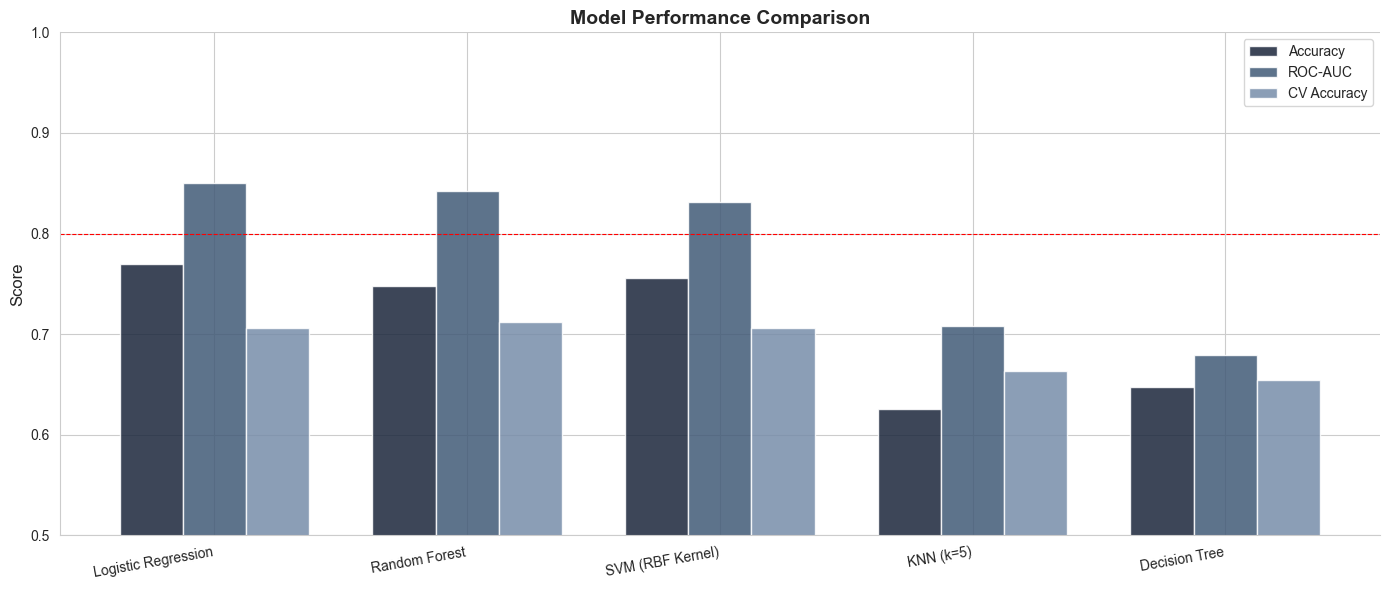

In [30]:
# Grouped bar chart
metrics = ['Accuracy', 'ROC-AUC', 'CV Accuracy']
x = np.arange(len(results_df))
width = 0.25
palette = ['#1B263B', '#415A77', '#778DA9']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, palette)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=10, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='red', linestyle='--', linewidth=0.8, label='0.8 threshold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Confusion Matrix

This chart shows how well the model makes predictions.

It compares:

Flights correctly predicted as delayed
Flights correctly predicted as not delayed
Flights incorrectly classified

A good model will have most values concentrated along the correct prediction areas.

This visualization helps us understand where the model performs well and where mistakes occur.

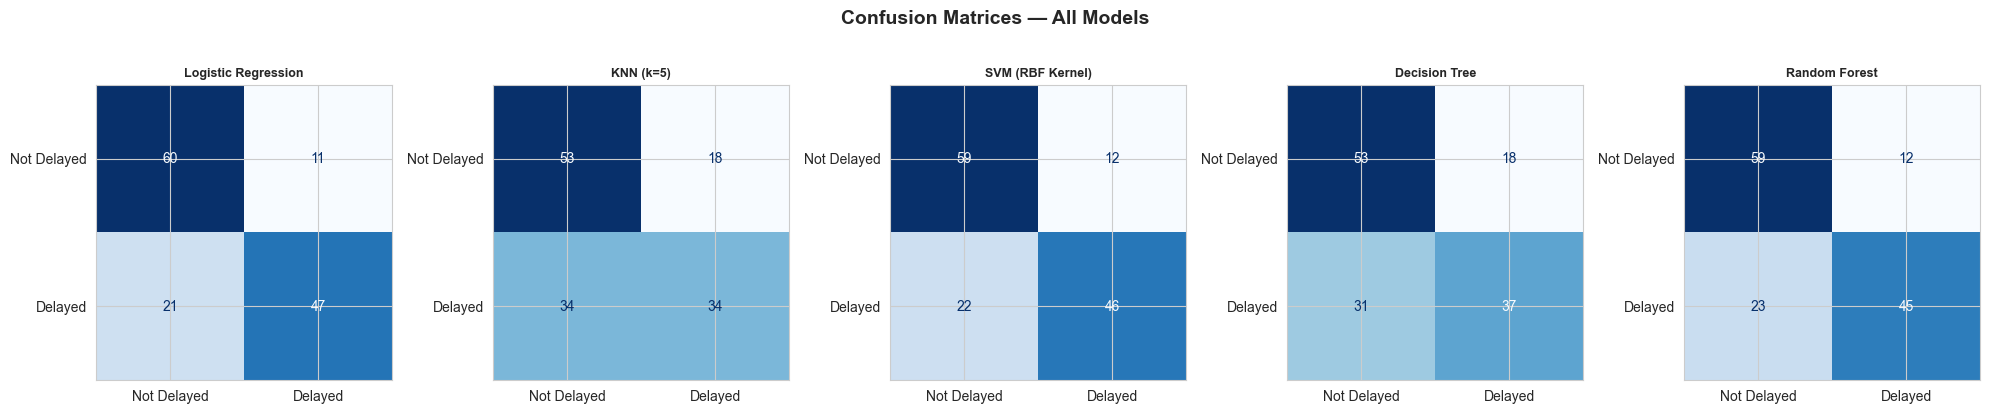

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ROC Curve

This chart evaluates how effectively the model separates delayed flights from non-delayed flights.

A curve that rises closer to the upper-left corner indicates stronger prediction performance.

The ROC curve helps determine whether the model can reliably distinguish between flights that are likely to be delayed and those that are not.

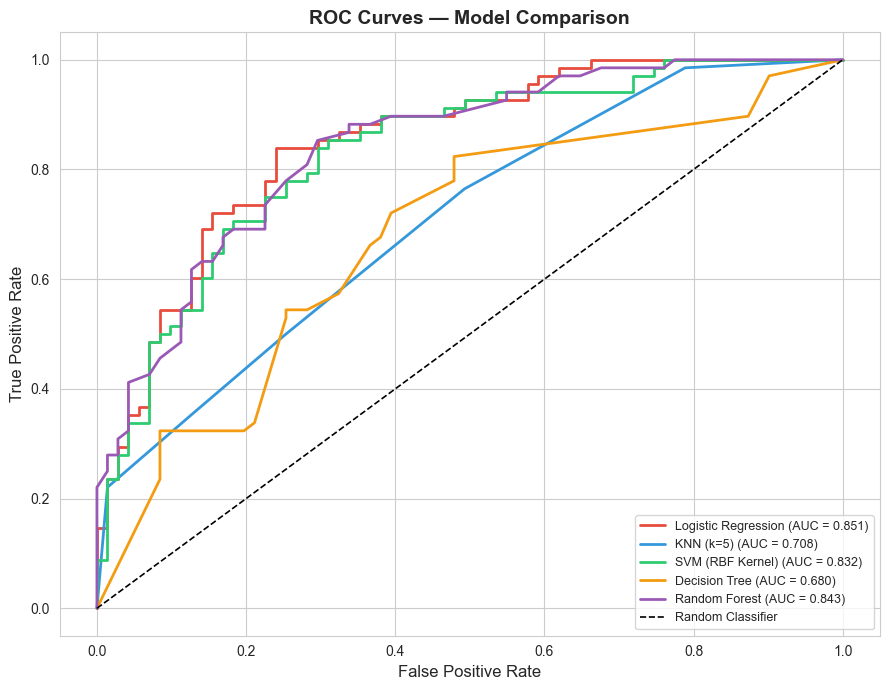

In [32]:
plt.figure(figsize=(9, 7))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {v['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
# Print classification report for the best model by ROC-AUC
best_model_name = results_df.index[0]
print(f'=== Classification Report: {best_model_name} ===')
print(classification_report(y_test, results[best_model_name]['y_pred'],
                              target_names=['Not Delayed', 'Delayed']))

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

 Not Delayed       0.74      0.85      0.79        71
     Delayed       0.81      0.69      0.75        68

    accuracy                           0.77       139
   macro avg       0.78      0.77      0.77       139
weighted avg       0.77      0.77      0.77       139



In [44]:
print(f'🔧 Tuning: Random Forest (typically best ensemble model for this type of task)\n')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'   Best CV ROC-AUC:  {grid_search.best_score_:.4f}')

🔧 Tuning: Random Forest (typically best ensemble model for this type of task)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
   Best CV ROC-AUC:  0.7920


In [43]:
# Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_processed)
y_prob_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

base_acc = results['Random Forest']['Accuracy']
base_auc = results['Random Forest']['ROC-AUC']

print('=== Tuning Results ===')
print(f'{"Metric":<20} {"Before Tuning":<20} {"After Tuning"}')
print('-' * 55)
print(f'{"Accuracy":<20} {base_acc:<20.4f} {tuned_acc:.4f}')
print(f'{"ROC-AUC":<20} {base_auc:<20.4f} {tuned_auc:.4f}')

print(f'\nClassification Report (Tuned Random Forest):')
print(classification_report(y_test, y_pred_tuned, target_names=['Not Delayed', 'Delayed']))

=== Tuning Results ===
Metric               Before Tuning        After Tuning
-------------------------------------------------------
Accuracy             0.7482               0.7410
ROC-AUC              0.8425               0.8381

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

 Not Delayed       0.71      0.83      0.77        71
     Delayed       0.79      0.65      0.71        68

    accuracy                           0.74       139
   macro avg       0.75      0.74      0.74       139
weighted avg       0.75      0.74      0.74       139



Feature Importance Chart

This chart identifies the factors that have the greatest influence on flight delay predictions.

The tallest bars represent the most important variables.

For example, factors such as previous delays, departure time, weather conditions, or visibility may appear as highly important.

This visualization helps airlines understand the main causes of delays and where operational improvements may be most effective.

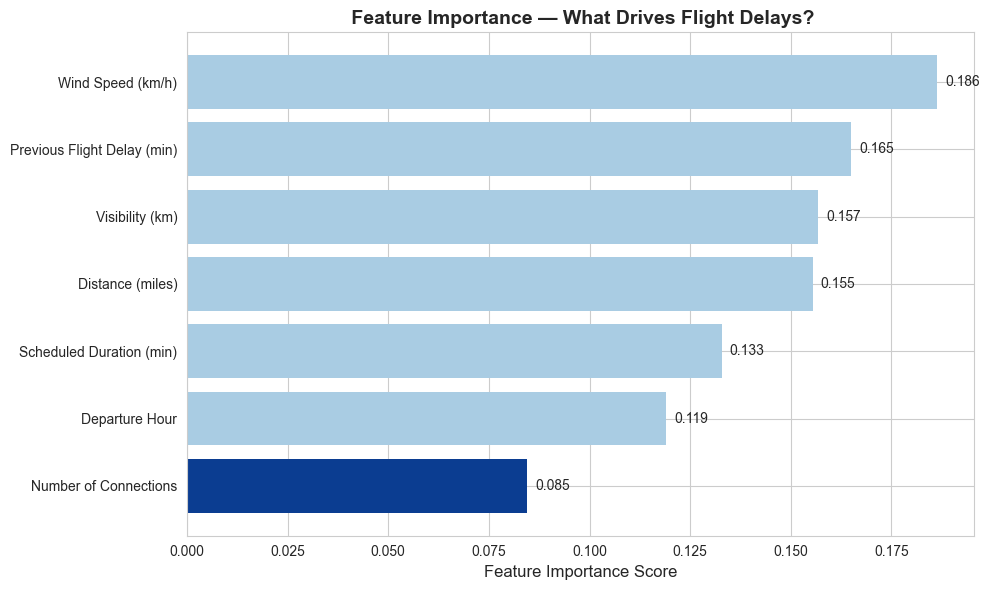

Top predictor of flight delay: Wind Speed (km/h) (importance = 0.1863)


In [42]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

colors_fi = ['#0B3D91' if i == importances.idxmax() else '#A9CCE3'
             for i in importances.index]

plt.figure(figsize=(10, 6))
bars = plt.barh(importances.index, importances.values, color=colors_fi[::-1], edgecolor='none')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title(' Feature Importance — What Drives Flight Delays?', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center', fontsize=10)

# Rename y-ticks
plt.yticks(range(len(importances)), [feature_labels.get(f, f) for f in importances.index])
plt.tight_layout()
plt.show()

top_feature = feature_labels.get(importances.idxmax(), importances.idxmax())
print(f'Top predictor of flight delay: {top_feature} (importance = {importances.max():.4f})')

In [41]:
def predict_delay_risk(departure_hour, scheduled_duration_min, distance_miles,
                        num_connections, wind_speed_kmh, visibility_km, prev_flight_delay_min):
    """
    Predicts flight delay risk using the tuned Random Forest model.
    Returns: prediction (Delayed/Not Delayed) and probability.
    """
    input_data = pd.DataFrame([{
        'departure_hour': departure_hour,
        'scheduled_duration_min': scheduled_duration_min,
        'distance_miles': distance_miles,
        'num_connections': num_connections,
        'wind_speed_kmh': wind_speed_kmh,
        'visibility_km': visibility_km,
        'prev_flight_delay_min': prev_flight_delay_min
    }])

    input_processed = preprocessor.transform(input_data)
    prediction = best_rf.predict(input_processed)[0]
    probability = best_rf.predict_proba(input_processed)[0][1]

    status = 'FLIGHT DELAYED' if prediction == 1 else 'FLIGHT ON TIME'
    risk_level = 'HIGH' if probability > 0.7 else ('MEDIUM' if probability > 0.4 else 'LOW')

    print(f'=====   Flight Delay Risk Assessment =====')
    print(f'Prediction:    {status}')
    print(f'Delay Probability: {probability*100:.1f}%')
    print(f'Risk Level:    {risk_level}')
    return prediction, probability

# --- Example 1: Evening flight with poor visibility and previous delays ---
print('--- EXAMPLE 1: High-Risk Flight ---')
predict_delay_risk(
    departure_hour=22, scheduled_duration_min=180, distance_miles=2000,
    num_connections=2, wind_speed_kmh=80, visibility_km=2, prev_flight_delay_min=85
)
print()

# --- Example 2: Morning short-haul with good conditions ---
print('--- EXAMPLE 2: Low-Risk Flight ---')
predict_delay_risk(
    departure_hour=8, scheduled_duration_min=90, distance_miles=500,
    num_connections=0, wind_speed_kmh=15, visibility_km=14, prev_flight_delay_min=5
)

--- EXAMPLE 1: High-Risk Flight ---
=====   Flight Delay Risk Assessment =====
Prediction:    FLIGHT DELAYED
Delay Probability: 91.0%
Risk Level:    HIGH

--- EXAMPLE 2: Low-Risk Flight ---
=====   Flight Delay Risk Assessment =====
Prediction:    FLIGHT ON TIME
Delay Probability: 5.5%
Risk Level:    LOW


(np.int64(0), np.float64(0.055))